1\. **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, linregress
from scipy.integrate import trapezoid
import pandas as pd
import seaborn as sns

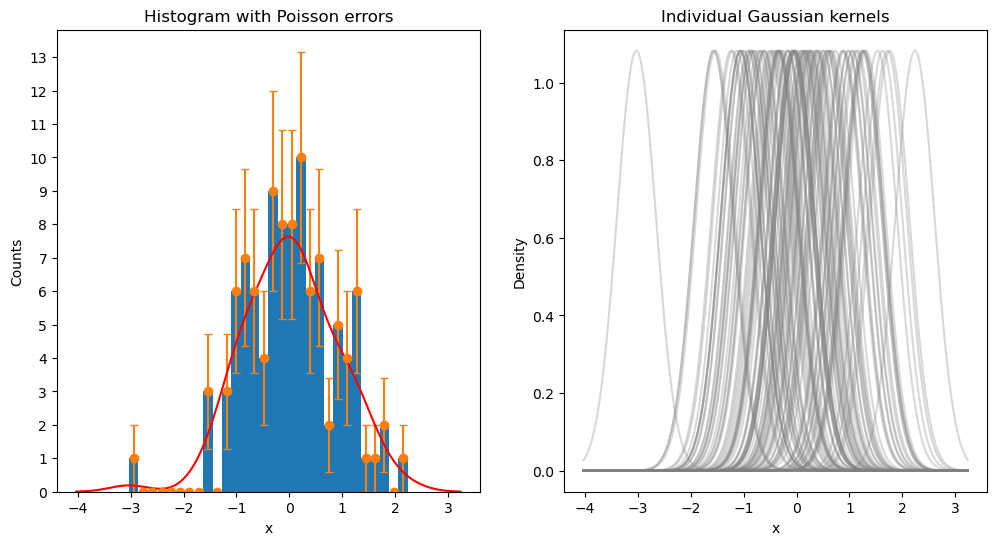

In [2]:
# Numpy array, x, of len(N) (with N=O(100)) with a variable normally distributed, with a given mean and standard deviation.
N = 100
mean = 0.0
std = 1.0
x = np.random.normal(loc=mean, scale=std, size=N)

# Histogram in pyplot taking properly care about the aesthetic.
bins = 30
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize=(12, 6))
counts, bin_edges,_ = ax1.hist(x, bins=bins) # " counts " is the number of counts in each bin and " bin_edges " an array with the limits of each bin.
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1]) # First one goes from 1 to end while second goes from 0 to one before the last.
errors = counts**0.5 # Poisson uncertainty.

ax1.errorbar(bin_centers, counts, yerr=errors, fmt='o', capsize=3)

ax1.set_ylabel("Counts")
ax1.set_xlabel("x")
ax1.set_yticks(np.arange(0,17)) # To have only integer labels.
ax1.set_title("Histogram with Poisson errors")

# Create a gaussian with the mean corresponding to the element value and std as a parameter that can be tuned.
sigma = 1.06 * x.std() * x.size ** (-1/5) # Bandwidth (std of each Gaussian).
xx = np.linspace(x.min() - 1, x.max() + 1, 500) # We extend limits because Gaussians have tails.
gaussians = np.array([norm.pdf(xx, loc=xi, scale=sigma) for xi in x]) # Each gaussian is evaluated in 500 points.

# In a separate plot, plot all the gaussian functions so obtained.
for g in gaussians:
    ax2.plot(xx, g, color='gray', alpha=0.3)
ax2.set_xlabel("x")
ax2.set_ylabel("Density")
ax2.set_title("Individual Gaussian kernels")

# (With np.sum()) all Gaussian functions summed and normalized so that the result is such that the integral coincides with the integral of the original histogram.
hist_bin_width = bin_edges[1] - bin_edges[0]
hist_integral = np.sum(hist_bin_width * counts) # This is the sum of the area (base multiplied by height) of each bin (rectangle).
kde = np.sum(gaussians,axis=0) # " axis=0 " Because each row has the points of each Gaussian.
kde_integral = trapezoid(kde, xx)
kde *= hist_integral / kde_integral # Normalization so that the result is such that the integral coincides with the integral of the original histogram.
ax1.plot(xx, kde, color='red', label='KDE')
plt.show()

2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


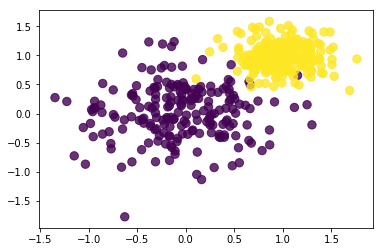

In [3]:
! wget https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
from IPython.display import Image
Image('two_categories_scatter_plot.png')

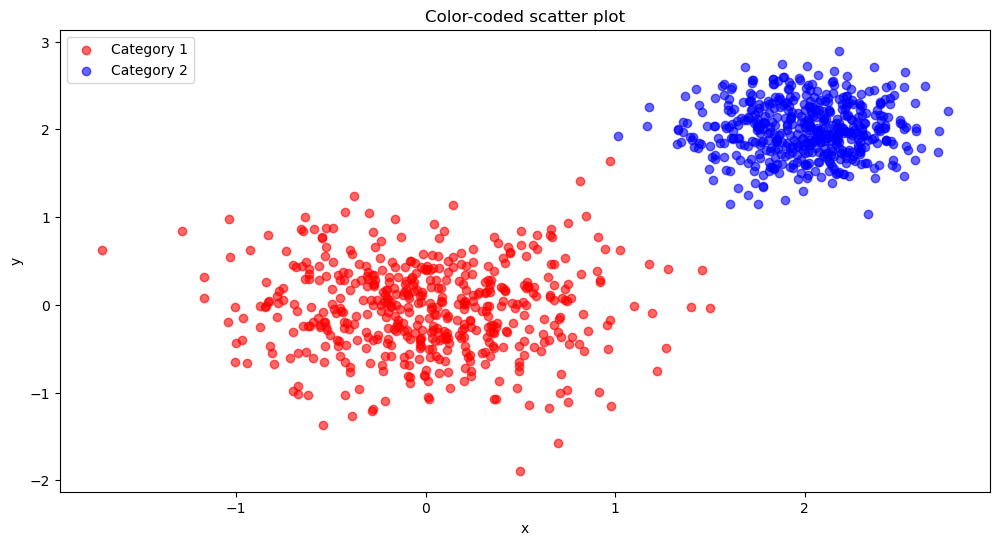

In [4]:
# Function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian.
def generate_2d_gaussian(mean, std, n):
    return np.random.normal(loc=mean, scale=std, size=(n, 2)) # Equivalent to generating two independent 1D normal arrays with the same " loc " and " scale ".

# Display the dataset in a scatter plot marking the two categories with different marker colors.
cat1 = generate_2d_gaussian(mean=0, std=0.5, n=500)
cat2 = generate_2d_gaussian(mean=2, std=0.3, n=500)
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title("Color-coded scatter plot")
ax.scatter(cat1[:, 0], cat1[:, 1], c='red', label='Category 1', alpha=0.6)
ax.scatter(cat2[:, 0], cat2[:, 1], c='blue', label='Category 2', alpha=0.6)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

3\. **Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```
Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)
* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot
* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot

       residuals  distances
0       1.100000       16.0
1      -1.950000        6.3
2      -7.200000        3.4
3      -4.150000        8.4
4      -6.590000        1.7
...          ...        ...
11126  -0.760000       14.4
11127   0.380000        7.5
11128   0.083333        1.7
11129   0.166667       19.1
11130   0.083333        2.6

[11131 rows x 2 columns]


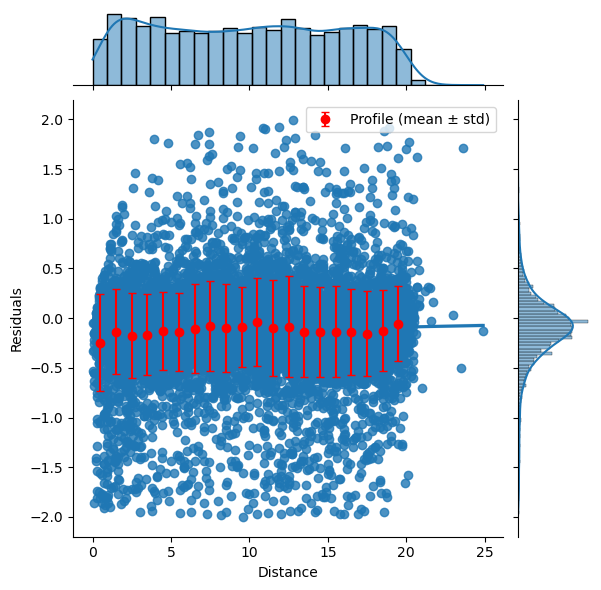

In [5]:
# Download the dataset and load it as a pandas dataframe.
# We use " item() " to extract the dictionary from the array so " pd.DataFrame " can read it.
residuals = np.load("residuals_261.npy",allow_pickle=True).item() 
df = pd.DataFrame(residuals)

# Inspect the dataset.
print(df)

# Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2.
df = df[abs(df["residuals"]) < 2]

# Linear regression of "residuals" versus "distances" using scipy.stats.linregress().
lreg = linregress(df["residuals"],df["distances"])

# Seaborn jointplot of "residuals" versus "distances" plotted, having seaborn performing a linear regression.
g = sns.jointplot(x="distances", y="residuals", data=df, kind="reg")

# Fill 3 numpy arrays.
   # x, serving as an array of bin centers for the "distance" variable.
lims = np.linspace(0,20,21)
width = (lims[1] - lims[0]) /2
x = lims[0:-1] + width

   # y, the mean values of the "residuals", estimated in slices (bins) of "distance".
y = [df.loc[(df["distances"] >= lims[i]) & (df["distances"] < lims[i+1]), "residuals"].mean() for i in range(len(lims)-1)]

   # erry, the standard deviation of the of the "residuals", estimated in slices (bins) of "distance".
erry = [df.loc[(df["distances"] >= lims[i]) & (df["distances"] < lims[i+1]),"residuals"].std() for i in range(len(lims)-1)]

# Plot the profile plot on top of the scatter plot.
g.ax_joint.errorbar(x, y, yerr=erry, fmt='o', color='red', label='Profile (mean ± std)',capsize=3)

g.ax_joint.set_xlabel("Distance")
g.ax_joint.set_ylabel("Residuals")
g.ax_joint.legend()

plt.show()